# Tools

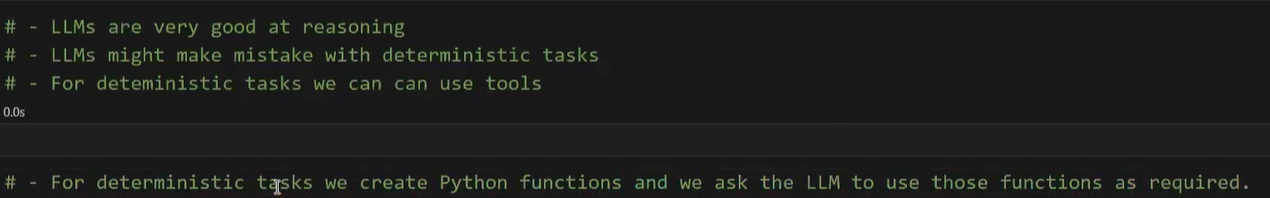

## Tool

In [4]:
def add_numbers(numbers):
    return sum(numbers)

add_numbers([1,2,3,4,5])

15

In [ ]:
# A tool is a JSON Schema that contains the details of those Python functions

### Tool Schema

In [2]:
# Level - 1
    # name: Exact name of the function
    # description: What this function is used for / what it actually does.

In [3]:
{
    'name': 'add_numbers', # Tells the LLM we have a tool with the name 'add_numbers'
    'description': 'It adds a list of numbers and returns the sum' # It tells the purpose of the function.
}

{'name': 'add_numbers',
 'description': 'It adds a list of numbers and returns the sum'}

In [ ]:
# Level - 2
    # In this section, we tell the LLM what parameters my function requires
    # Parameters:
        # type: object
        # properties: {...}
        # required: [...]

In [6]:
{
    "parameters": {
        "type": "object",
        "properties": {
            "numbers": {
                "type": "array",
                "items": "number"
            }
        },
        "required": ["numbers"]
    }
}

{'parameters': {'type': 'object',
  'properties': {'numbers': {'type': 'array', 'items': 'number'}},
  'required': ['numbers']}}

In [57]:
function_schema  = {
    "name": "add_numbers",
    "description": "It adds a Python list of numbers and returns the sum. Example: [1,2,3,4]",
    "parameters": {
        "type": "object",
        "properties": {
            "numbers": {
                "type": "array",
                "items": {"type": "number"},
                "description": "A Python list of numbers."
            }
        },
        "required": ["numbers"]
    }
}

function_schema

{'name': 'add_numbers',
 'description': 'It adds a Python list of numbers and returns the sum. Example: [1,2,3,4]',
 'parameters': {'type': 'object',
  'properties': {'numbers': {'type': 'array',
    'items': {'type': 'number'},
    'description': 'A Python list of numbers.'}},
  'required': ['numbers']}}

In [58]:
numbers_tool = {
    "type": "function",
    "function": function_schema
}

numbers_tool

{'type': 'function',
 'function': {'name': 'add_numbers',
  'description': 'It adds a Python list of numbers and returns the sum. Example: [1,2,3,4]',
  'parameters': {'type': 'object',
   'properties': {'numbers': {'type': 'array',
     'items': {'type': 'number'},
     'description': 'A Python list of numbers.'}},
   'required': ['numbers']}}}

## Making API call using the tool

In [59]:
import os
from openai import OpenAI

In [60]:
client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))

In [61]:
def make_apicall_with_tool(prompt, tool):
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        tools=[tool]
    )

    return response

In [62]:
prompt = "Add 10,.5 20.2"

result = make_apicall_with_tool(prompt, numbers_tool)

In [63]:
result.choices[0].message.tool_calls

[ChatCompletionMessageFunctionToolCall(id='call_IdwhMVDH3aWNF2cZbbzD055y', function=Function(arguments='{"numbers":[10.5,20.2]}', name='add_numbers'), type='function')]

In [64]:
result.choices[0].message.content

In [68]:
result.choices[0].message.tool_calls[0].function.arguments

'{"numbers":[10.5,20.2]}'

In [69]:
import json

In [71]:
args = json.loads(result.choices[0].message.tool_calls[0].function.arguments)
args

{'numbers': [10.5, 20.2]}

In [73]:
args['numbers']

[10.5, 20.2]

In [74]:
add_numbers(args['numbers'])

30.7

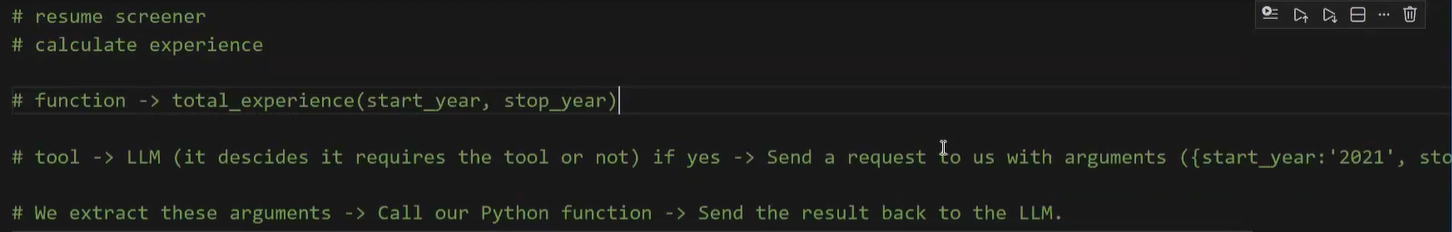